## Global Terrorism Analysis

### 1. Know your Data

#### Import Libraries

In [1]:
# Install cufflinks
#!pip install cufflinks

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.offline import iplot
import plotly as py
import plotly.tools as tls
import cufflinks as cf
%matplotlib inline

In [3]:
py.offline.init_notebook_mode(connected=True)
cf.go_offline()

In [4]:
df = pd.read_csv(r"C:\Users\Akshit\Advance Python\global terrorism.csv", encoding='ISO-8859-1',low_memory=False)

### Dataset First View

In [5]:
df.head()

,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


### Dataset Rows & Column Count

In [6]:
rows,cols =df.shape
print(f'There are {rows} rows and {cols} columns in the dataset.')

There are 181691 rows and 135 columns in the dataset.


In [7]:
from IPython.display import display,Markdown

rows,cols = df.shape
display(Markdown(f'There are **{rows}** rows and **{cols}** columns in the dataset.'))

There are **181691** rows and **135** columns in the dataset.

In [8]:
from IPython.display import display, HTML

rows,cols = df.shape
display(HTML(f'<p>There are <b style="color:red;">{rows}</b> rows and <b style="color:red;">{cols}</b> columns in the dataset.</p>'))

### Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB


### Duplicate values

In [10]:
duplicate_rows = df.duplicated().sum()
print(f'There are {duplicate_rows} duplicate rows in the dataset')

There are 0 duplicate rows in the dataset


### Missing Values/ Null Values

In [11]:
missing_values = df.isnull().sum()
print(missing_values)

eventid            0
iyear              0
imonth             0
iday               0
approxdate    172452
               ...  
INT_LOG            0
INT_IDEO           0
INT_MISC           0
INT_ANY            0
related       156653
Length: 135, dtype: int64


### Missing no Library Install

In [12]:
#!pip install missingno PyWaveLets

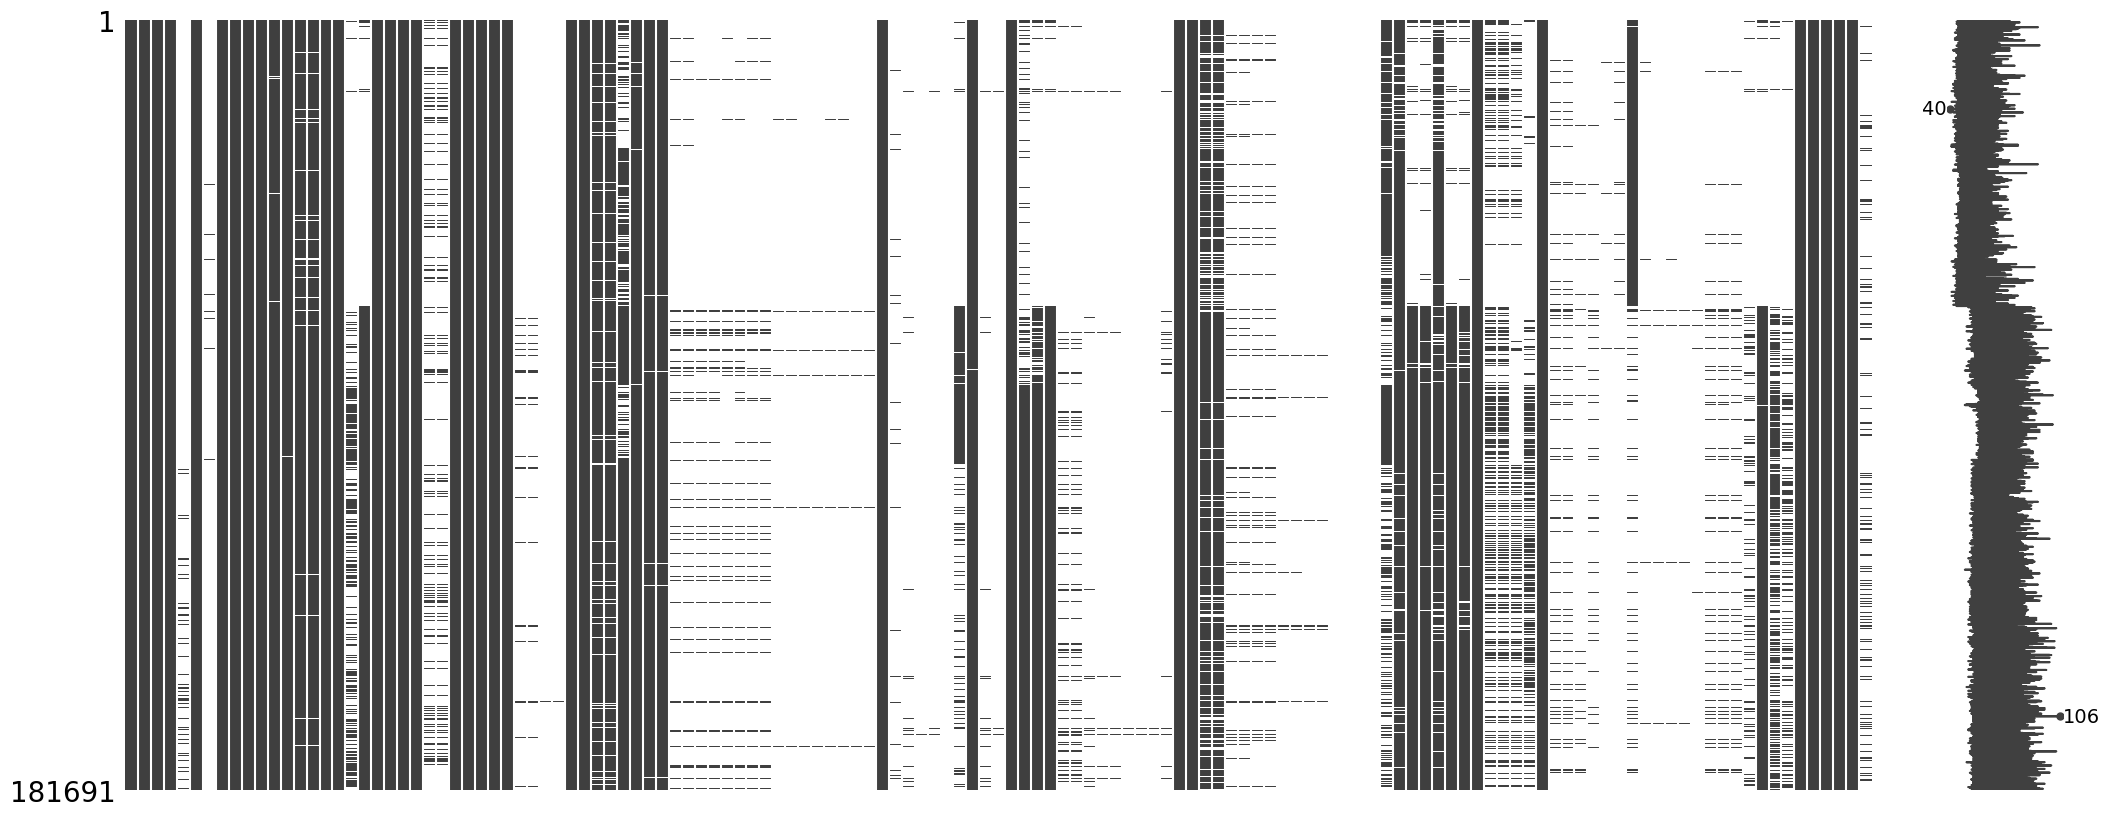

In [13]:
import missingno as msno
msno.matrix(df)
plt.show()

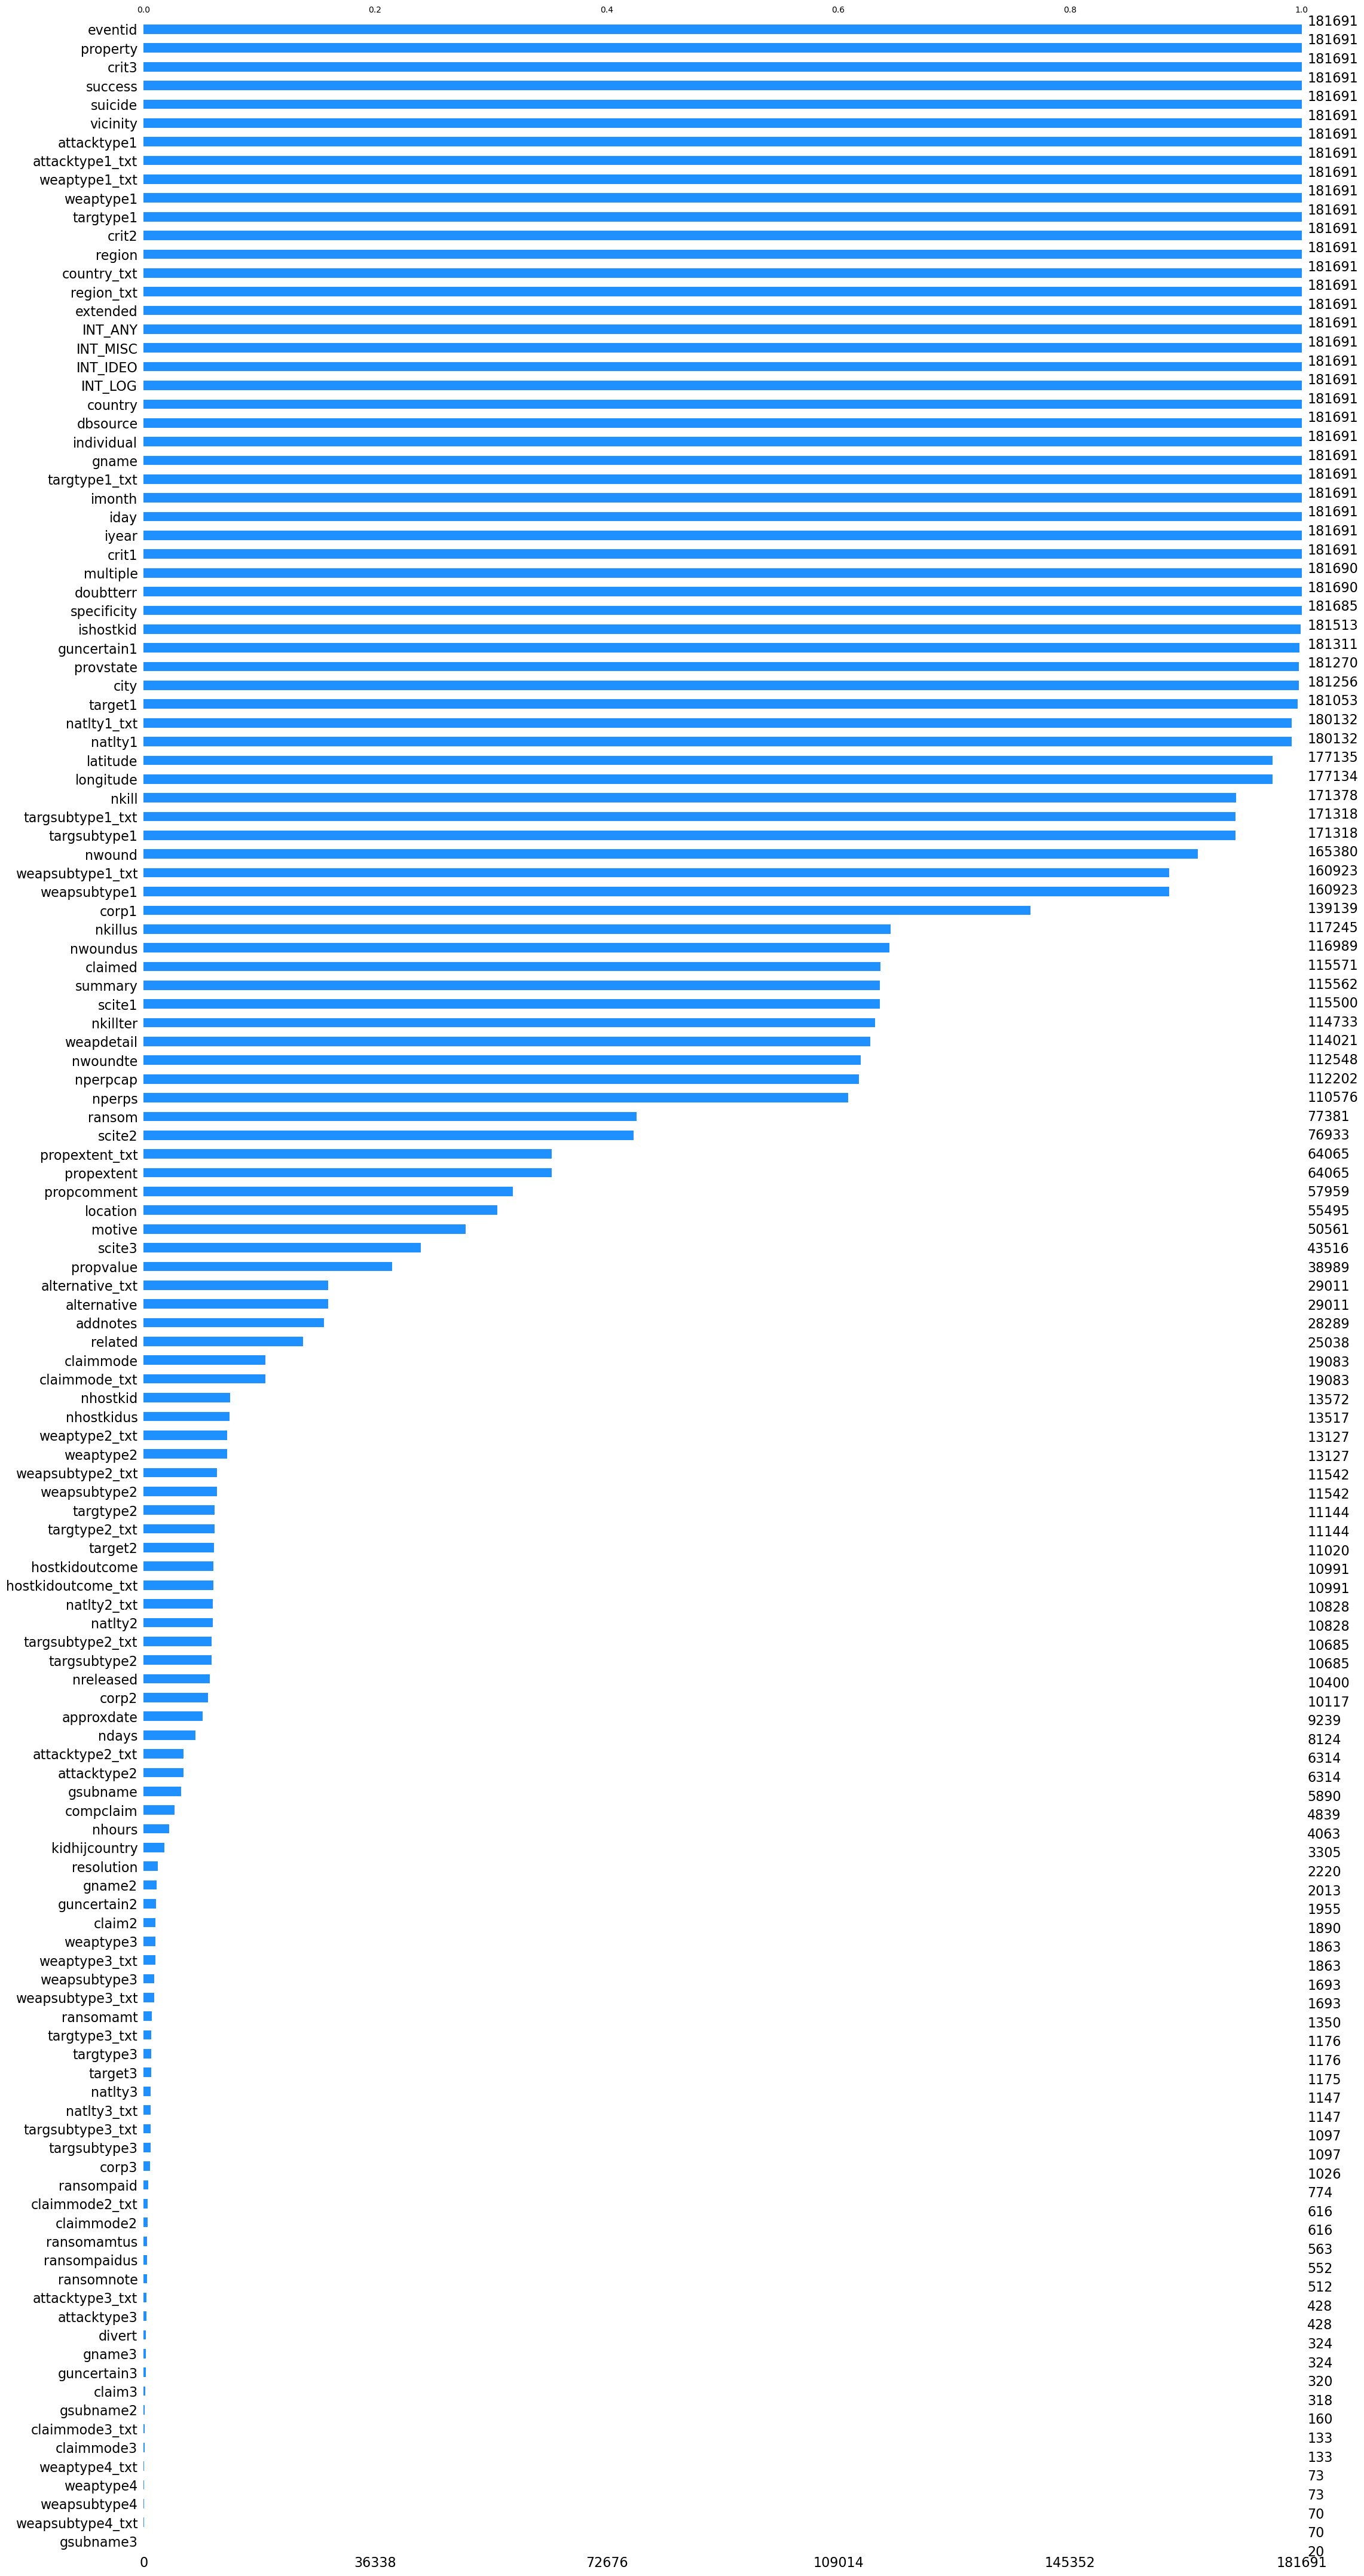

In [14]:
# Sort columns by missing values (descding)
sorted_columns = missing_values.sort_values(ascending=False).index

# Reorder Data frame
df_sorted = df[sorted_columns]

msno.bar(df_sorted, color="dodgerblue")

plt.show()

## 2. Understanding your variables

### Dataset columns

In [15]:
columns = df.columns

print("Columns in dataset")

for column in columns:
    print(column)

Columns in dataset
eventid
iyear
imonth
iday
approxdate
extended
resolution
country
country_txt
region
region_txt
provstate
city
latitude
longitude
specificity
vicinity
location
summary
crit1
crit2
crit3
doubtterr
alternative
alternative_txt
multiple
success
suicide
attacktype1
attacktype1_txt
attacktype2
attacktype2_txt
attacktype3
attacktype3_txt
targtype1
targtype1_txt
targsubtype1
targsubtype1_txt
corp1
target1
natlty1
natlty1_txt
targtype2
targtype2_txt
targsubtype2
targsubtype2_txt
corp2
target2
natlty2
natlty2_txt
targtype3
targtype3_txt
targsubtype3
targsubtype3_txt
corp3
target3
natlty3
natlty3_txt
gname
gsubname
gname2
gsubname2
gname3
gsubname3
motive
guncertain1
guncertain2
guncertain3
individual
nperps
nperpcap
claimed
claimmode
claimmode_txt
claim2
claimmode2
claimmode2_txt
claim3
claimmode3
claimmode3_txt
compclaim
weaptype1
weaptype1_txt
weapsubtype1
weapsubtype1_txt
weaptype2
weaptype2_txt
weapsubtype2
weapsubtype2_txt
weaptype3
weaptype3_txt
weapsubtype3
weapsubtype3_

### Dataset Describe

In [16]:
summary = df.describe()

print(summary)

            eventid          iyear         imonth           iday  \
count  1.816910e+05  181691.000000  181691.000000  181691.000000   
mean   2.002705e+11    2002.638997       6.467277      15.505644   
std    1.325957e+09      13.259430       3.388303       8.814045   
min    1.970000e+11    1970.000000       0.000000       0.000000   
25%    1.991021e+11    1991.000000       4.000000       8.000000   
50%    2.009022e+11    2009.000000       6.000000      15.000000   
75%    2.014081e+11    2014.000000       9.000000      23.000000   
max    2.017123e+11    2017.000000      12.000000      31.000000   

            extended        country         region       latitude  \
count  181691.000000  181691.000000  181691.000000  177135.000000   
mean        0.045346     131.968501       7.160938      23.498343   
std         0.208063     112.414535       2.933408      18.569242   
min         0.000000       4.000000       1.000000     -53.154613   
25%         0.000000      78.000000       

### Check unique values for each variable

In [17]:
unique_countries = df['country_txt'].unique()
print(unique_countries)

['Dominican Republic' 'Mexico' 'Philippines' 'Greece' 'Japan'
 'United States' 'Uruguay' 'Italy' 'East Germany (GDR)' 'Ethiopia'
 'Guatemala' 'Venezuela' 'West Germany (FRG)' 'Switzerland' 'Jordan'
 'Spain' 'Brazil' 'Egypt' 'Argentina' 'Lebanon' 'Ireland' 'Turkey'
 'Paraguay' 'Iran' 'United Kingdom' 'Colombia' 'Bolivia' 'Nicaragua'
 'Netherlands' 'Belgium' 'Canada' 'Australia' 'Pakistan' 'Zambia' 'Sweden'
 'Costa Rica' 'South Yemen' 'Cambodia' 'Israel' 'Poland' 'Taiwan' 'Panama'
 'Kuwait' 'West Bank and Gaza Strip' 'Austria' 'Czechoslovakia' 'India'
 'France' 'South Vietnam' 'Brunei' 'Zaire'
 "People's Republic of the Congo" 'Portugal' 'Algeria' 'El Salvador'
 'Thailand' 'Haiti' 'Sudan' 'Morocco' 'Cyprus' 'Myanmar' 'Afghanistan'
 'Peru' 'Chile' 'Honduras' 'Yugoslavia' 'Ecuador' 'New Zealand' 'Malaysia'
 'Singapore' 'Botswana' 'Jamaica' 'Chad' 'North Yemen' 'Andorra' 'Syria'
 'South Korea' 'United Arab Emirates' 'South Africa' 'Kenya' 'Iraq'
 'Somalia' 'Tanzania' 'Sri Lanka' 'Namibia' '

In [18]:
unique_year=df['iyear'].unique()
print(unique_year)

[1970 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1981 1986 1982
 1983 1984 1985 1987 1988 1989 1990 1991 1992 1994 1995 1996 1997 1998
 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012
 2013 2014 2015 2016 2017]


### Data wrangling Code

In [19]:
print(df.isnull().sum())

eventid            0
iyear              0
imonth             0
iday               0
approxdate    172452
               ...  
INT_LOG            0
INT_IDEO           0
INT_MISC           0
INT_ANY            0
related       156653
Length: 135, dtype: int64


In [20]:
pd.set_option('display.max_rows',None)
print(df.dtypes)

eventid                 int64
iyear                   int64
imonth                  int64
iday                    int64
approxdate             object
extended                int64
resolution             object
country                 int64
country_txt            object
region                  int64
region_txt             object
provstate              object
city                   object
latitude              float64
longitude             float64
specificity           float64
vicinity                int64
location               object
summary                object
crit1                   int64
crit2                   int64
crit3                   int64
doubtterr             float64
alternative           float64
alternative_txt        object
multiple              float64
success                 int64
suicide                 int64
attacktype1             int64
attacktype1_txt        object
attacktype2           float64
attacktype2_txt        object
attacktype3           float64
attacktype

In [21]:
pd.reset_option('display.max_rows')
print(df.dtypes)

eventid        int64
iyear          int64
imonth         int64
iday           int64
approxdate    object
               ...  
INT_LOG        int64
INT_IDEO       int64
INT_MISC       int64
INT_ANY        int64
related       object
Length: 135, dtype: object


In [22]:
df.rename(columns={'iyear':'Year','imonth':'Month','iday':'Day','country_txt':'Country','provstate':'state',
                  'region_txt':'Region','attacktype1_txt':'AttackType','target1':'Target','nkill':'Killed',
                  'nwound':'Wounded','summary':'Summary','gname':'Group','targtype1_txt':'Target_type',
                  'weaptype1_txt':'Weapon_type','motive':'Motive'},inplace=True)

In [23]:
data=df[['Year','Month','Day','Country','state','Region','city','latitude','longitude','AttackType','Killed',
         'Wounded','Target','Summary','Group','Target_type','Weapon_type','Motive']]

In [24]:
data.head()

,Year,Month,Day,Country,state,Region,city,latitude,longitude,AttackType,Killed,Wounded,Target,Summary,Group,Target_type,Weapon_type,Motive
0,1970,7,2,Dominican Republic,NaN,Central America & Caribbean,Santo Domingo,18.456792,-69.951164,Assassination,1.0,0.0,Julio Guzman,NaN,MANO-D,Private Citizens & Property,Unknown,NaN
1,1970,0,0,Mexico,Federal,North America,Mexico city,19.371887,-99.086624,Hostage Taking (Kidnapping),0.0,0.0,"Nadine Chaval, daughter",NaN,23rd of September Communist League,Government (Diplomatic),Unknown,NaN
2,1970,1,0,Philippines,Tarlac,Southeast Asia,Unknown,15.478598,120.599741,Assassination,1.0,0.0,Employee,NaN,Unknown,Journalists & Media,Unknown,NaN
3,1970,1,0,Greece,Attica,Western Europe,Athens,37.997490,23.762728,Bombing/Explosion,NaN,NaN,U.S. Embassy,NaN,Unknown,Government (Diplomatic),Explosives,NaN
4,1970,1,0,Japan,Fukouka,East Asia,Fukouka,33.580412,130.396361,Facility/Infrastructure Attack,NaN,NaN,U.S. Consulate,NaN,Unknown,Government (Diplomatic),Incendiary,NaN


### Chart-1 Count of Terrorist Actvities Each Year

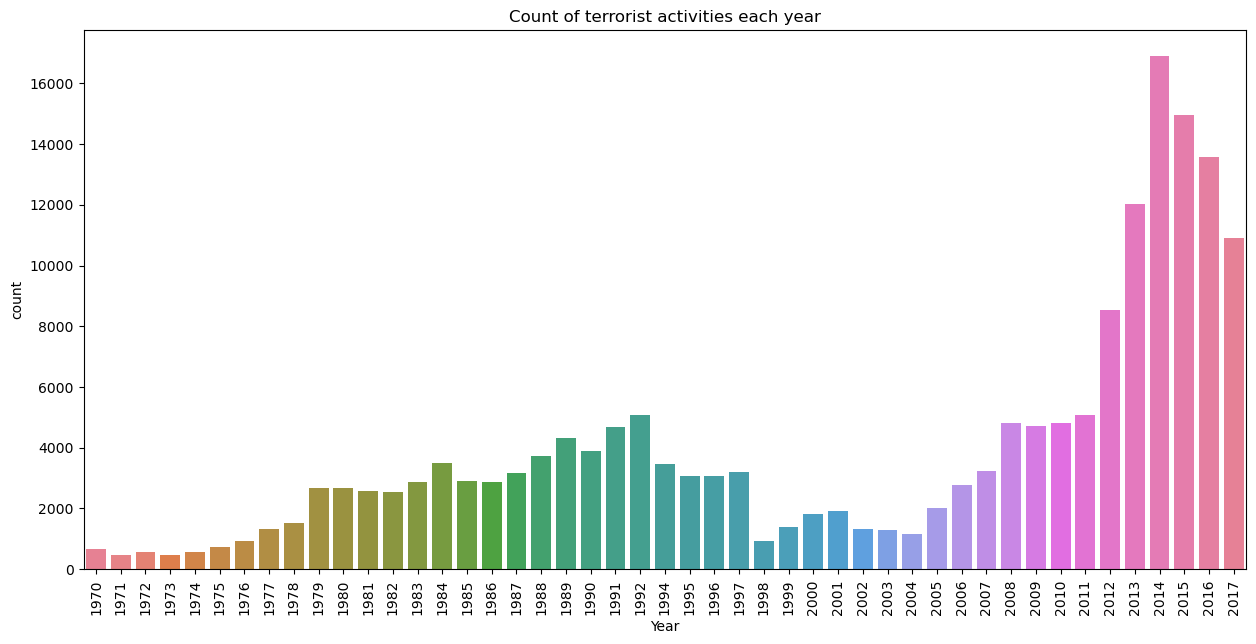

In [25]:
plt.figure(figsize=(15,7))
sns.countplot(data=data, x='Year', hue='Year', legend=False, palette='husl')
#palettes - viridis, coolwarm, Set2, husl, Paired, pastel
plt.title('Count of terrorist activities each year')
plt.xticks(rotation=90)
plt.show()

#Note: hue='Year',legend=False both are used to remove error

### Chart 2 - Count of terroist activities by region

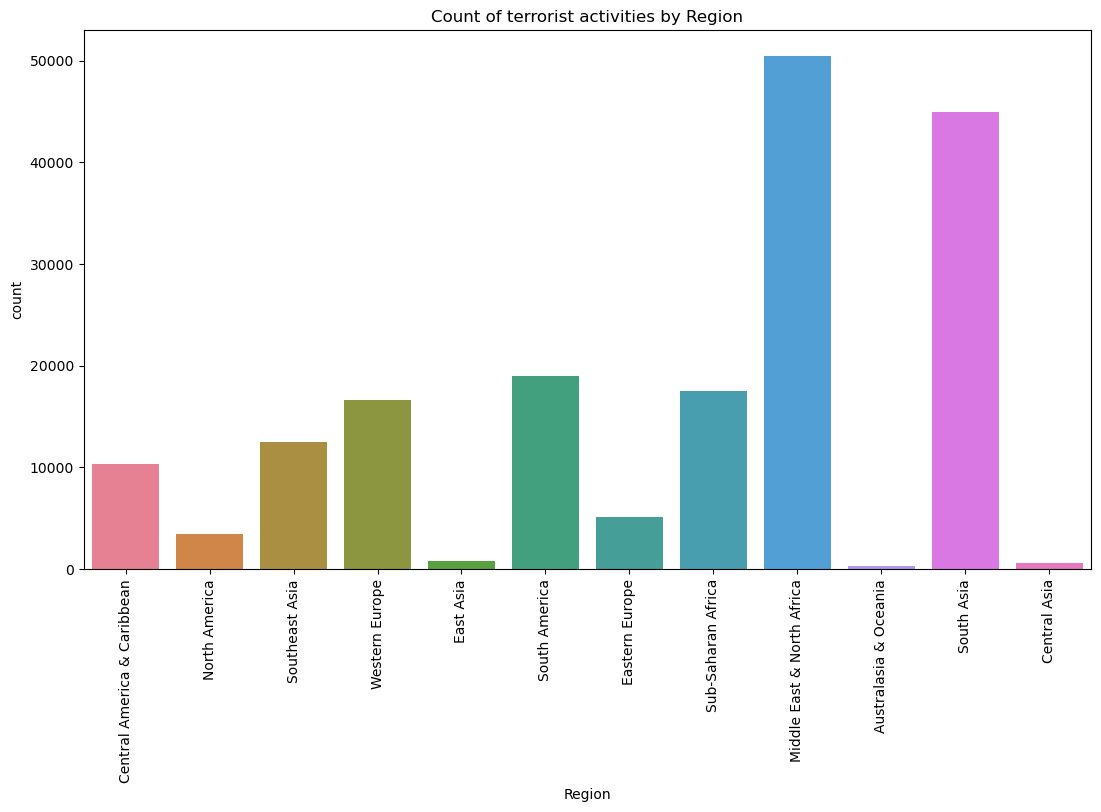

In [26]:
plt.figure(figsize=(13,7))
sns.countplot(data=data, x='Region', hue='Region', legend=False, palette='husl')
plt.title('Count of terrorist activities by Region')
plt.xticks(rotation=90)
plt.show()

### Chart 3 - Number of people killed by terror attack

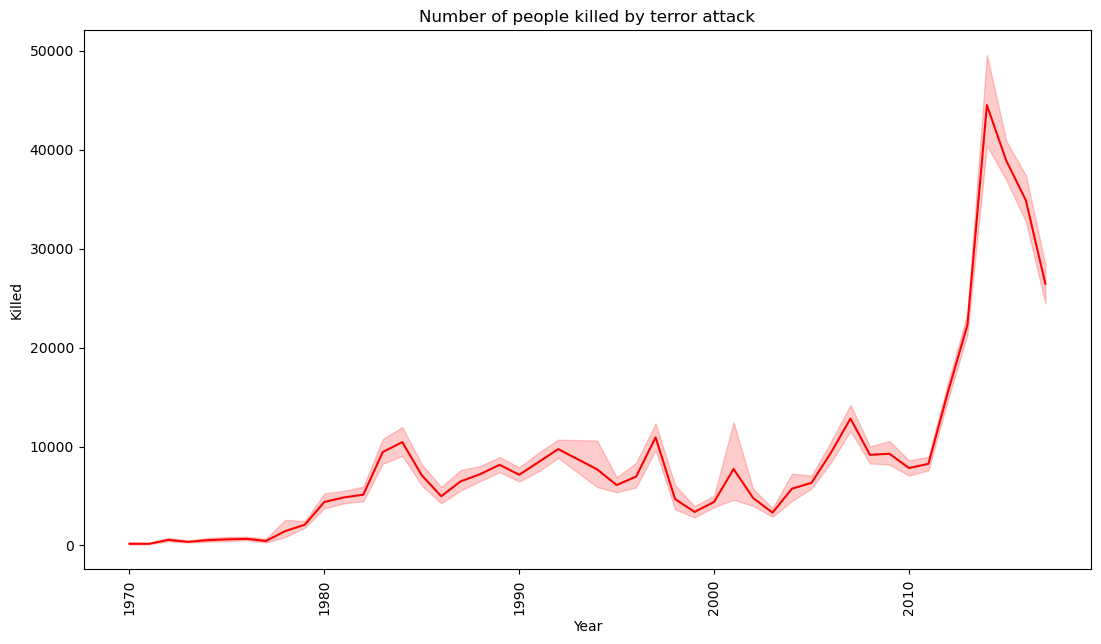

In [27]:
plt.figure(figsize=(13,7))
sns.lineplot(data=data, x='Year',y='Killed', estimator='sum', color='red') #estimator='mean', 'max', 'count'
plt.title('Number of people killed by terror attack')
plt.xticks(rotation=90)
plt.show()

### Chart 4 -Attack types

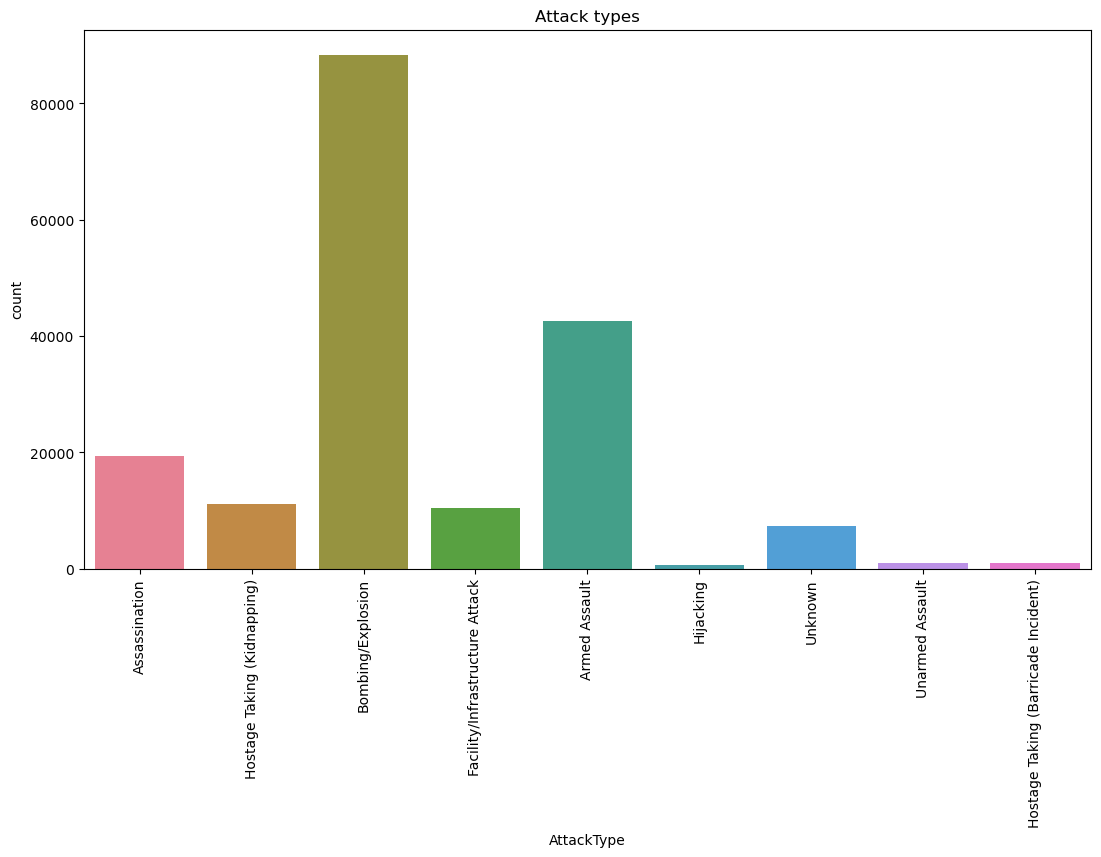

In [28]:
plt.figure(figsize=(13,7))
sns.countplot(data=data, x='AttackType', hue='AttackType', legend=False, palette='husl')
plt.title('Attack types')
plt.xticks(rotation=90)
plt.show()

### Chart 5 - Top 10 Terroist group with highest no of Attacks

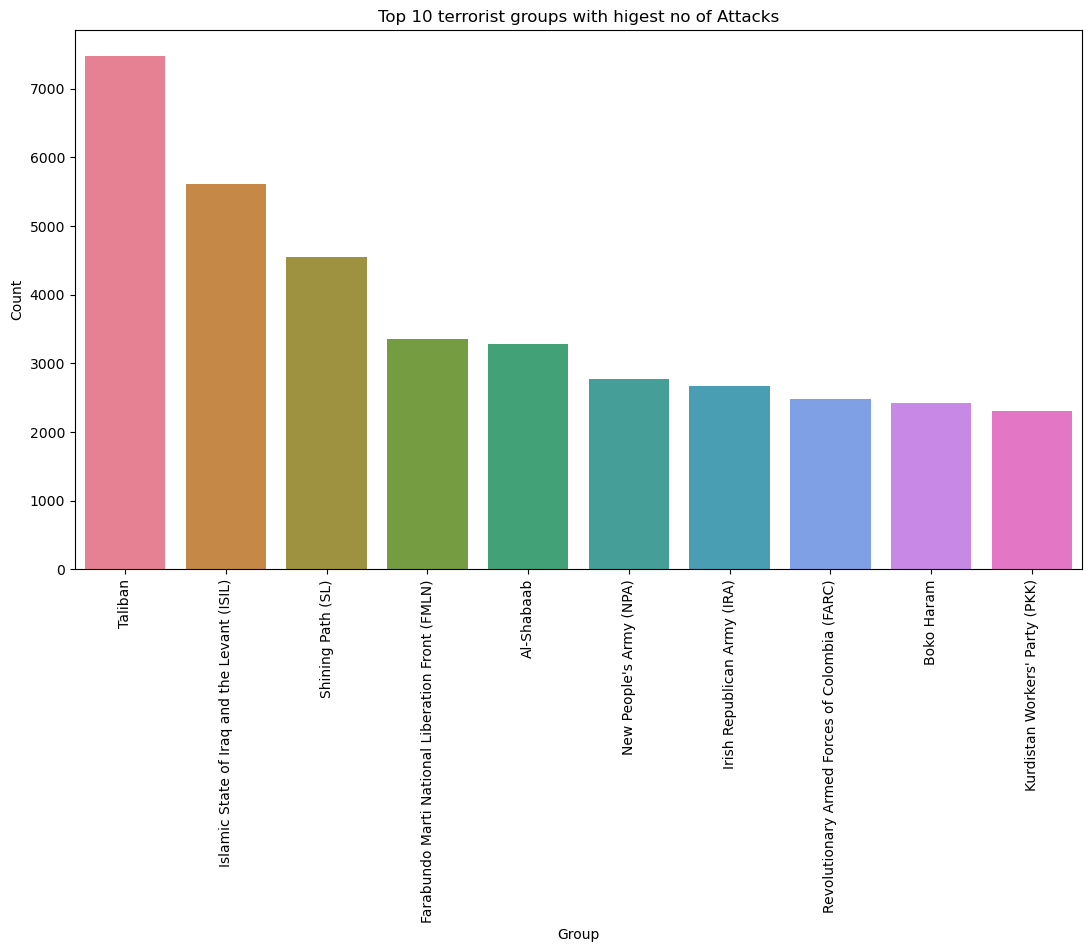

In [29]:
plt.figure(figsize=(13,7))

group_data = data[data['Group'] != 'Unknown']['Group'].value_counts().head(10)

sns.barplot(x=group_data.index, y=group_data.values, hue=group_data.index, legend=False, palette='husl')

plt.title('Top 10 terrorist groups with higest no of Attacks')
plt.xticks(rotation=90)
plt.xlabel('Group')
plt.ylabel('Count')
plt.show()

### Chart 6 - Fatalities vs injuries

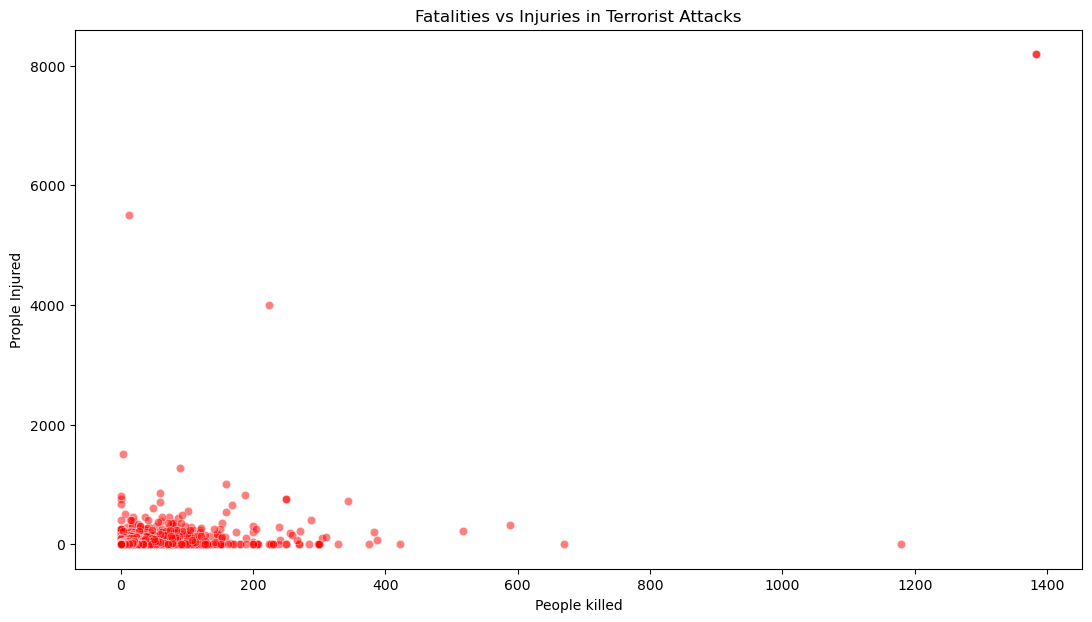

In [30]:
plt.figure(figsize=(13,7))
sns.scatterplot(data=data, x='Killed', y='Wounded', alpha=0.5, color='red')
plt.title('Fatalities vs Injuries in Terrorist Attacks')
plt.xlabel('People killed')
plt.ylabel('Prople Injured')
plt.show()

### Chart 7 - Percentage of different Attack Type

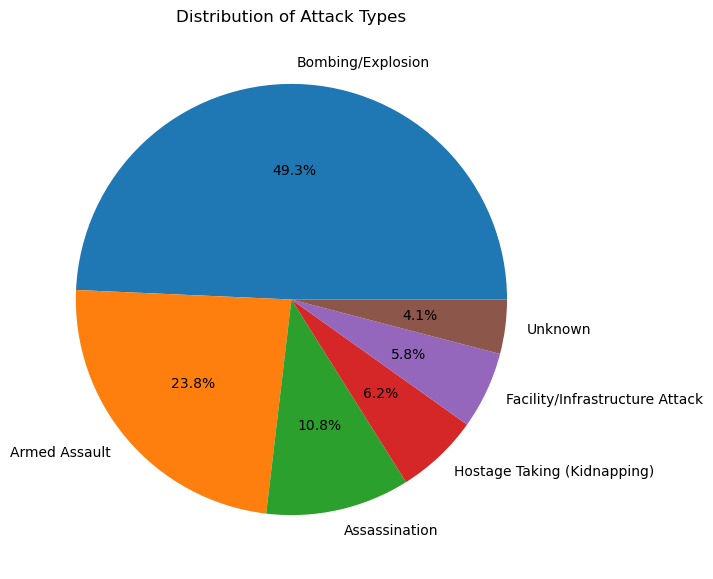

In [31]:
attack_counts = df['AttackType'].value_counts()
plt.figure(figsize=(13,7))
plt.pie(attack_counts[:6], labels=attack_counts.index[:6], autopct='%1.1f%%', colors=sns.color_palette('tab10'))
plt.title('Distribution of Attack Types')
plt.show()

### Chart 8 - Heatmap of Attacks by Region & Year

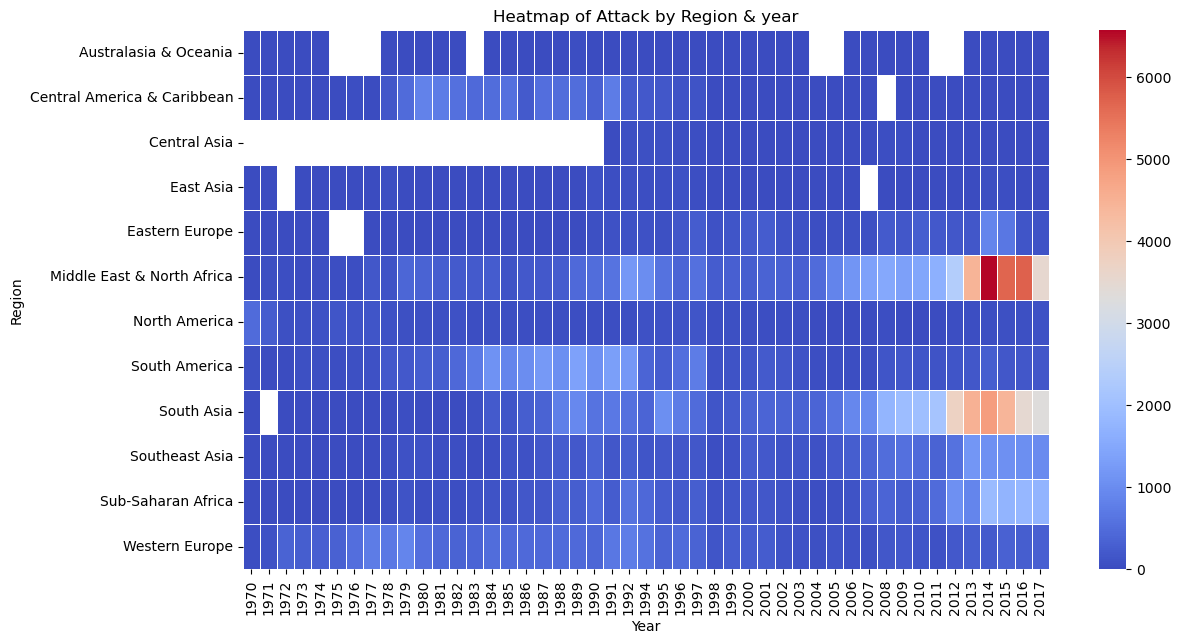

In [32]:
plt.figure(figsize=(13,7))
region_year_pivot = df.pivot_table(index='Region', columns='Year', values='Killed', aggfunc='count')
sns.heatmap(region_year_pivot, cmap='coolwarm', linewidth=0.5)
plt.title('Heatmap of Attack by Region & year')
plt.xlabel('Year')
plt.ylabel('Region')
plt.show()

In [33]:
region_year_pivot_table = df.pivot_table(index='Region', columns='Year', values='Killed', aggfunc='count')
print(region_year_pivot_table)

Year                          1970   1971   1972   1973   1974   1975   1976  \
Region                                                                         
Australasia & Oceania          1.0    1.0    8.0    1.0    1.0    NaN    NaN   
Central America & Caribbean    6.0    3.0    3.0    5.0   10.0    9.0   29.0   
Central Asia                   NaN    NaN    NaN    NaN    NaN    NaN    NaN   
East Asia                      1.0    1.0    NaN    2.0    4.0    2.0    2.0   
Eastern Europe                 3.0    1.0    1.0    1.0    2.0    NaN    NaN   
Middle East & North Africa    21.0   31.0   41.0   15.0   33.0   37.0   38.0   
North America                470.0  243.0   73.0   63.0  101.0  152.0  116.0   
South America                 58.0   19.0   25.0   69.0   68.0   40.0   74.0   
South Asia                     1.0    NaN    1.0    1.0    2.0    3.0    4.0   
Southeast Asia                10.0    4.0   14.0    2.0    3.0    5.0    9.0   
Sub-Saharan Africa             3.0    2.

### Chart 9 - Box plot of Casualties by Region

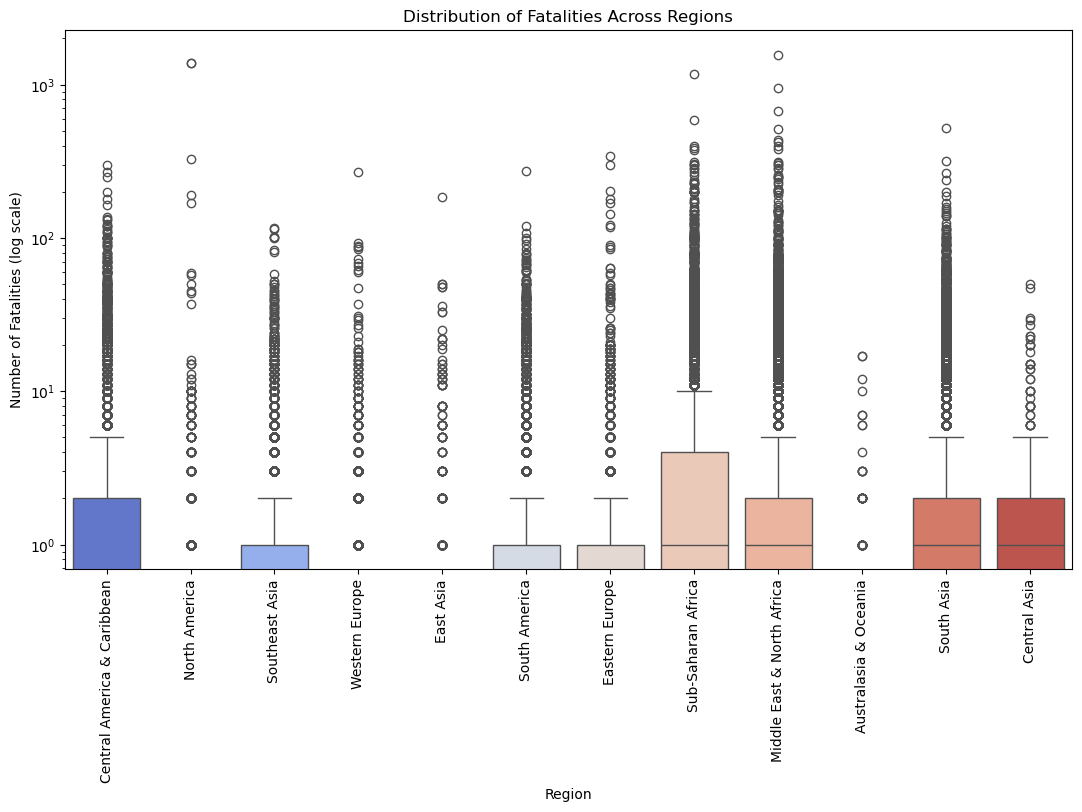

In [34]:
plt.figure(figsize=(13,7))
sns.boxplot(data=df, x='Region', y='Killed', hue='Region', legend=False, palette='coolwarm')
plt.xticks(rotation=90)
plt.yscale('log')
plt.title('Distribution of Fatalities Across Regions')
plt.xlabel('Region')
plt.ylabel('Number of Fatalities (log scale)')
plt.show()

### Chart 10 - Top 10 Deadliest Years

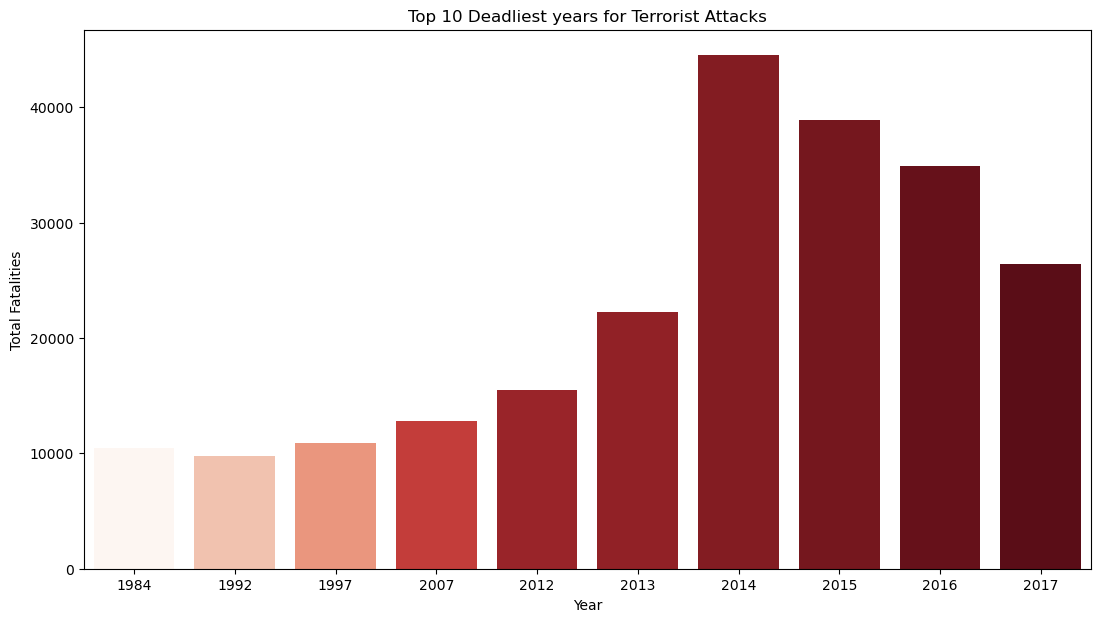

In [35]:
plt.figure(figsize=(13,7))
deadliest_years = df.groupby('Year')['Killed'].sum().nlargest(10)
sns.barplot(x=deadliest_years.index, y=deadliest_years.values, hue=deadliest_years.index, legend=False, palette='Reds')
plt.title('Top 10 Deadliest years for Terrorist Attacks')
plt.xlabel('Year')
plt.ylabel('Total Fatalities')
plt.show()

### Chart 11 - Geographic Attack Density (Choropleth Map - Plotly)

In [36]:
import plotly.express as px

df_map = df.groupby(['Country'])['Killed'].sum().reset_index()
fig = px.choropleth(df_map, locations="Country", locationmode="country names",
                   color='Killed', hover_name="Country",
                   color_continuous_scale='Reds', title="Terrorist Attack Falatilies by Country",
                   height=500)

# fig.update_layout(
#     autosize=True # Only needed if you're embedding in a resizable container
#)
fig.show()

C:\Users\Akshit\AppData\Local\Temp\ipykernel_13304\3128336221.py:4: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



### Chart 12 - Network Graph: Attack Connections Between Countries

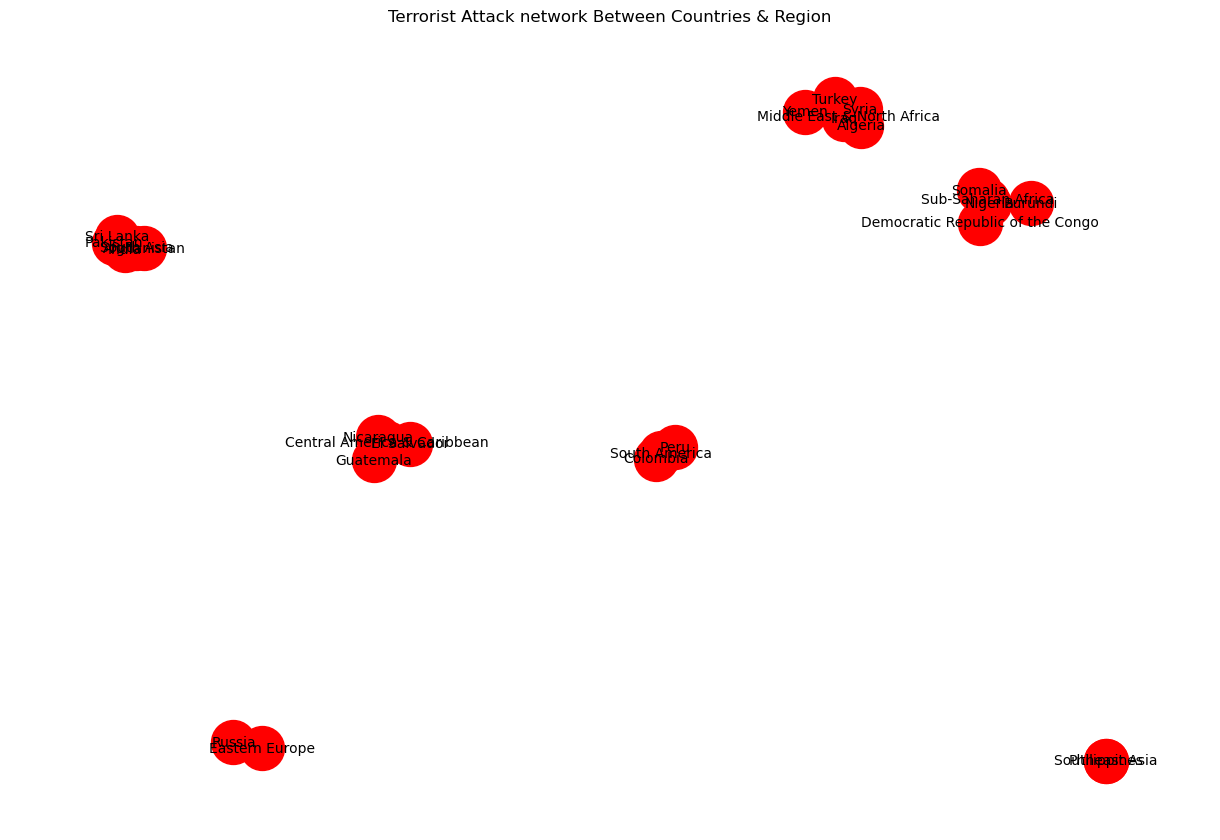

In [41]:
import networkx as nx

plt.figure(figsize=(12,8))
G = nx.Graph()

top_routes = df.groupby(['Country', 'Region'])['Killed'].sum().reset_index().nlargest(20,'Killed')

for _, row in top_routes.iterrows():
    G.add_edge(row['Country'],row['Region'], weight=row['Killed'])

pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='red', edge_color='yellow', node_size=1000, font_size=10)
plt.title('Terrorist Attack network Between Countries & Region')
plt.show()

### Chart 13 - Animated line chart: Yearly Attack Trends (plotly)

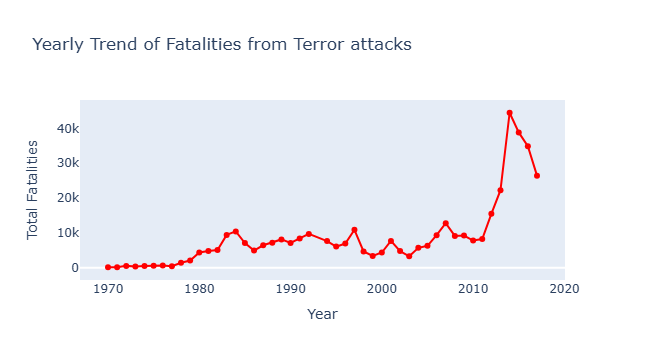

In [47]:
import plotly.graph_objects as go

df_yearly = df.groupby('Year')['Killed'].sum().reset_index()

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_yearly['Year'], y=df_yearly['Killed'], mode='lines+markers', line=dict(color='red')))

fig.update_layout(title="Yearly Trend of Fatalities from Terror attacks",
                 xaxis_title="Year",
                 yaxis_title="Total Fatalities",
                 xaxis=dict(showgrid=False),
                 yaxis=dict(showgrid=False))

fig.show()

### Chart 14 - Sunburst Chart: Attack Breakdown by Region & Attack type

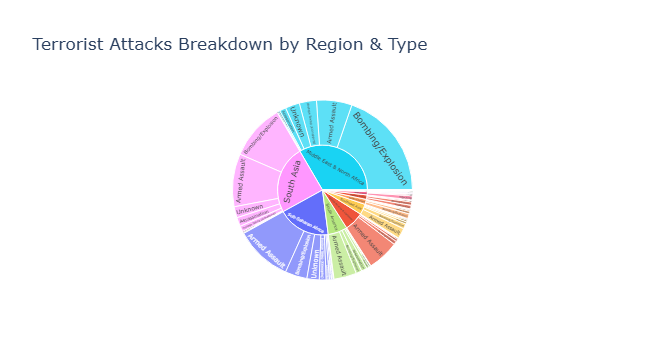

In [48]:
fig = px.sunburst(df, path=['Region', 'AttackType'], values='Killed', color='Region',
                 color_continuous_scale='RdBu', title='Terrorist Attacks Breakdown by Region & Type')

fig.show()